# 4. Quy hoạch thực nghiệm

Notebook cốt lõi cho Chương 7 và CLO3-CLO4. Dữ liệu UCI được dùng để hiệu chỉnh mức trung
bình và độ phân tán; treatment effect được xác định trước theo ý nghĩa thực tiễn, không lấy
từ chênh lệch quan sát giữa các nhóm.

In [1]:
from pathlib import Path
import warnings

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
ALPHA = 0.05
ROOT = Path("../..")
DATA_RAW = ROOT / "data" / "raw"
DATA_OUT = ROOT / "data" / "processed"
FIGURES = ROOT / "report" / "figures"
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

import statsmodels.formula.api as smf
from statsmodels.stats.power import TTestIndPower

df = pd.read_csv(DATA_OUT / "student_mat_clean.csv")
rng = np.random.default_rng(RANDOM_SEED)

## 4.1. Kế hoạch thực nghiệm

- **Experimental unit:** một học sinh.
- **Treatment:** chương trình ôn tập có hướng dẫn trước kỳ thi cuối kỳ.
- **Control:** học theo chương trình thông thường.
- **Response:** điểm `G3`, thang 0-20.
- **Thiết kế:** phân bổ ngẫu nhiên 1:1, block theo trường.
- **Replication:** nhiều học sinh trong mỗi treatment arm.
- **Giả thuyết:** `H0: mean_treatment - mean_control = 0`.
- **Effect mục tiêu chính:** tăng 1,5 điểm G3, được chọn trước vì có ý nghĩa thực tiễn.

## 4.2. Cỡ mẫu theo effect mục tiêu

In [2]:
sd_g3 = df["G3"].std(ddof=1)
power_solver = TTestIndPower()
effects = [0.5, 1.0, 1.5, 2.0]
design_rows = []
for delta in effects:
    standardized = delta / sd_g3
    n_per_arm = power_solver.solve_power(
        effect_size=standardized, alpha=ALPHA, power=0.80, ratio=1, alternative="two-sided"
    )
    design_rows.append({
        "target_effect_points": delta,
        "standardized_effect_d": standardized,
        "n_per_arm": int(np.ceil(n_per_arm)),
        "total_sample_size": int(2 * np.ceil(n_per_arm)),
    })
design_table = pd.DataFrame(design_rows)
design_table.to_csv(DATA_OUT / "doe_design_scenarios.csv", index=False)
design_table

## 4.3. Mô phỏng một thí nghiệm hoàn toàn ngẫu nhiên

In [3]:
PRIMARY_EFFECT = 1.5
N_PER_ARM = int(design_table.loc[design_table["target_effect_points"] == PRIMARY_EFFECT, "n_per_arm"].iloc[0])
n_total = 2 * N_PER_ARM

assignment = np.repeat([0, 1], N_PER_ARM)
rng.shuffle(assignment)
baseline = rng.normal(df["G3"].mean(), sd_g3, n_total)
outcome = np.clip(baseline + PRIMARY_EFFECT * assignment, 0, 20)
trial = pd.DataFrame({"treatment": assignment, "G3": outcome})

trial_model = smf.ols("G3 ~ treatment", data=trial).fit()
estimate = trial_model.params["treatment"]
ci = trial_model.conf_int().loc["treatment"]
print(f"Ước lượng treatment effect: {estimate:.3f}")
print(f"95% CI: [{ci.iloc[0]:.3f}, {ci.iloc[1]:.3f}]")
print(f"p-value: {trial_model.pvalues['treatment']:.4g}")

Ước lượng treatment effect: 2.264
95% CI: [1.245, 3.284]
p-value: 1.706e-05


## 4.4. Monte Carlo: power và Type I error

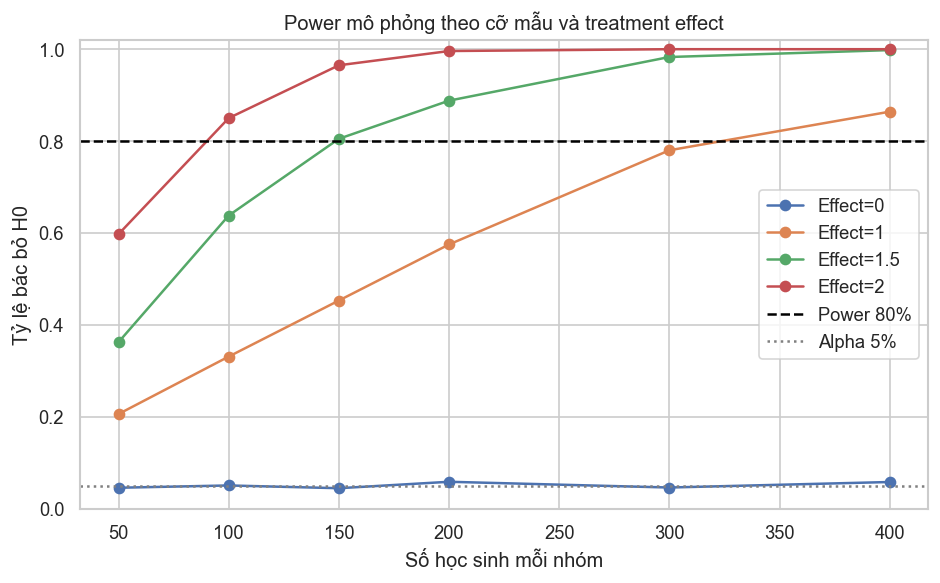

In [4]:
N_SIMULATIONS = 2000
sample_sizes = [50, 100, 150, 200, 300, 400]
effect_grid = [0.0, 1.0, 1.5, 2.0]
simulation_rows = []

for effect in effect_grid:
    for n_arm in sample_sizes:
        control = rng.normal(df["G3"].mean(), sd_g3, size=(N_SIMULATIONS, n_arm))
        treated = rng.normal(df["G3"].mean() + effect, sd_g3, size=(N_SIMULATIONS, n_arm))
        control = np.clip(control, 0, 20)
        treated = np.clip(treated, 0, 20)
        _, p_values = stats.ttest_ind(treated, control, axis=1, equal_var=False)
        estimates = treated.mean(axis=1) - control.mean(axis=1)
        simulation_rows.append({
            "effect_points": effect,
            "n_per_arm": n_arm,
            "rejection_rate": np.mean(p_values < ALPHA),
            "mean_estimated_effect": np.mean(estimates),
        })

simulation_results = pd.DataFrame(simulation_rows)
simulation_results.to_csv(DATA_OUT / "doe_simulation_results.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for effect, group in simulation_results.groupby("effect_points"):
    ax.plot(group["n_per_arm"], group["rejection_rate"], marker="o", label=f"Effect={effect:g}")
ax.axhline(0.80, color="black", linestyle="--", label="Power 80%")
ax.axhline(0.05, color="gray", linestyle=":", label="Alpha 5%")
ax.set(xlabel="Số học sinh mỗi nhóm", ylabel="Tỷ lệ bác bỏ H0", ylim=(0, 1.02),
       title="Power mô phỏng theo cỡ mẫu và treatment effect")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "doe_power_curve.png", dpi=150, bbox_inches="tight")
plt.show()
simulation_results

Khi effect bằng 0, rejection rate xấp xỉ Type I error. Khi effect lớn hơn 0, rejection
rate là empirical power. Sai khác nhỏ so với công thức lý thuyết xuất hiện do mô phỏng và
việc giới hạn điểm trong khoảng 0-20.

## 4.5. Mở rộng factorial 2x2

In [5]:
# Hai factor đều là can thiệp có thể phân bổ ngẫu nhiên.
n_cell = 80
factorial = pd.DataFrame({
    "guided_review": np.repeat([0, 0, 1, 1], n_cell),
    "study_reminders": np.repeat([0, 1, 0, 1], n_cell),
})
noise = rng.normal(0, sd_g3, len(factorial))
factorial["G3"] = np.clip(
    df["G3"].mean()
    + 1.2 * factorial["guided_review"]
    + 0.6 * factorial["study_reminders"]
    + 0.4 * factorial["guided_review"] * factorial["study_reminders"]
    + noise,
    0, 20,
)
factorial_model = smf.ols("G3 ~ guided_review * study_reminders", data=factorial).fit()
factorial_results = pd.DataFrame({
    "term": factorial_model.params.index,
    "coefficient": factorial_model.params.values,
    "p_value": factorial_model.pvalues.values,
})
factorial_results.to_csv(DATA_OUT / "doe_factorial_results.csv", index=False)
factorial.groupby(["guided_review", "study_reminders"])["G3"].agg(["count", "mean", "std"]), factorial_results

## Kết luận

- Randomization giúp cân bằng các yếu tố gây nhiễu trung bình giữa treatment và control.
- Replication làm giảm sai số ước lượng; blocking theo trường có thể tăng độ chính xác.
- Với độ lệch chuẩn quan sát khoảng 4,58, effect nhỏ đòi hỏi mẫu lớn.
- Factorial 2x2 cho phép ước lượng hai main effects và interaction trong cùng một thiết kế.
- Kết quả mô phỏng minh họa cách thiết kế; nó không chứng minh chương trình giả định thực
  sự làm tăng `G3`.